# DS-7331 Lab Two -

### By Ahmad Salama, Titus Karuri, Eman Meraj, Sue Camara

In [57]:
# ---------------------------------------------------------
# Python Library Setup: Check and Install Required Dependencies
# ---------------------------------------------------------
import sys
import subprocess
import importlib.util as imp_util

# List of required libraries\packages for this notebook
required_packages = [
    "pandas",
    "missingno",
    "seaborn",
    "matplotlib",
    "math",
    "scikit-learn",
    "numpy"
]

for package in required_packages:
    # iterate over the required packages and if any is not installed, trigger a pip command
    # to install.
    if imp_util.find_spec(package) is None:
        print(f"Package '{package}' is not installed. Installing now...")
        # run the pip command
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.DEVNULL
        )
        print(f"Package '{package}' installed successfully.\n")
    else:
        print(f"Package '{package}' is already installed.\n")

# ---------------------------------------------------------
# Import required libraries\packages
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import os as os
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
from sklearn import metrics as mt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import os

Package 'pandas' is already installed.

Package 'missingno' is already installed.

Package 'seaborn' is already installed.

Package 'matplotlib' is already installed.

Package 'math' is already installed.

Package 'scikit-learn' is not installed. Installing now...
Package 'scikit-learn' installed successfully.

Package 'numpy' is already installed.



In [58]:
def print_section_header(title, char="=", width=80):
    print(char * width)
    print(title)
    print(char * width)

In [61]:
DATASET_NAME = "default_of_credit_card_clients.csv"
data_path = os.path.join(os.getcwd(), "data", DATASET_NAME)

# load the dataset
df = pd.read_csv(data_path, header=1)

print_section_header(title="INITIAL DATA EXPLORATION")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

INITIAL DATA EXPLORATION
Dataset shape: (30000, 25)

First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


As you can see above, the missing values matrix show a solid and uninterrupted block across all features. This indicate that there are no explicit missing values in the dataset. This observation is consistent with the dataset documentation, which states that the data does not contain any missing values.

In [62]:
# check data types
print_section_header("Data Types")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe()

Data Types
ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

Basic Statistics:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Missing Values Analysis


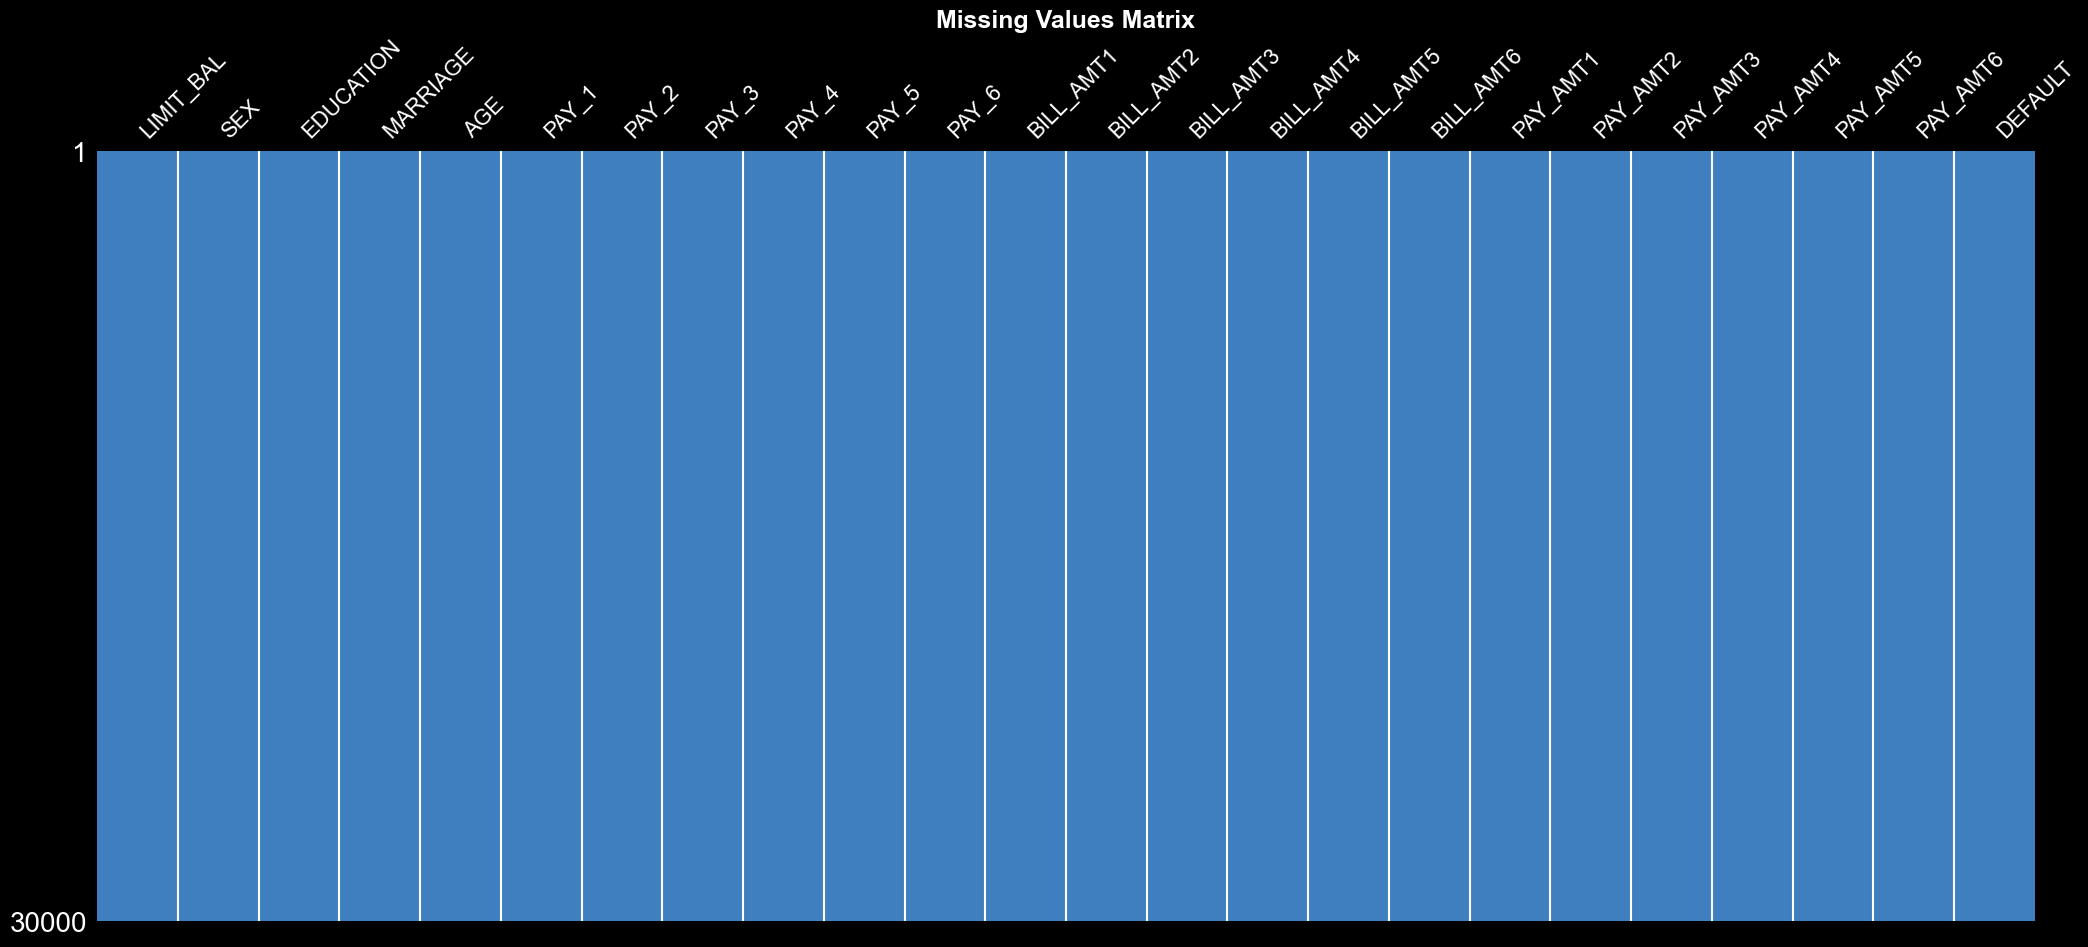

In [55]:
# Visualize dataset completeness using a missingno matrix plot
print_section_header("Data Quality & Missing Values Analysis")
msno.matrix(
    df,
    color=(0.25, 0.5, 0.75),
    sparkline=False
)
plt.title("Missing Values Matrix", fontsize=18, fontweight="bold")
plt.show()

As you can see above, the missing values matrix show a solid and uninterrupted block across all features. This indicate that there are no explicit missing values in the dataset. This observation is consistent with the dataset documentation, which states that the data does not contain any missing values.

In [ ]:
# Verify that the target variable contains only binary decision values (0 = no default, 1 = default)
unique = df["default payment next month"].unique()
print(unique)

As part of the data quality analysis, we verified that the target variable (`default payment next month`) contains only binary decision values (0 and 1). This validation step ensures that the dataset is appropriate for binary classification models.

While our data doesn't have any missing values, during the exploratory analysis, we observed that some categorical features contain values that are undocumented. To better understand the extent and impact of these values, we visualize the distribution of the those variables using heatmaps. As we have observed in the previous labs, the count of the undocumented values are very small and we will handle them by merging into another appropriate categories to preserve data.

In [ ]:
# Handle categorical variables
print_section_header("CATEGORICAL VARIABLE Analysis & Cleanup")


SEX unique values: [1 0]
SEX
1    18112
0    11888
Name: count, dtype: int64


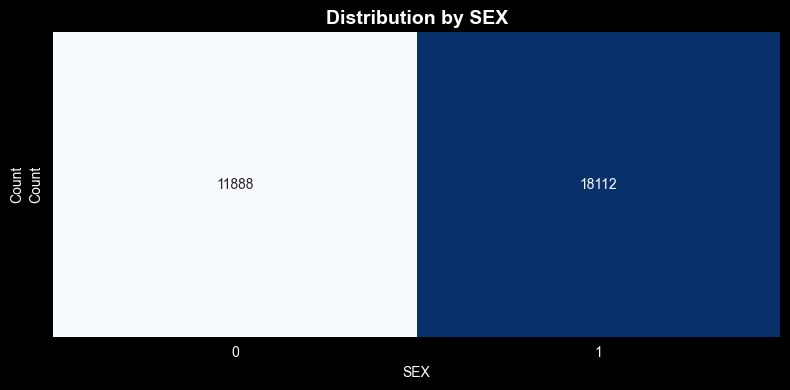


EDUCATION unique values: ['university' 'graduate_school' 'high_school' 'other']
EDUCATION
university         14030
graduate_school    10585
high_school         4917
other                468
Name: count, dtype: int64


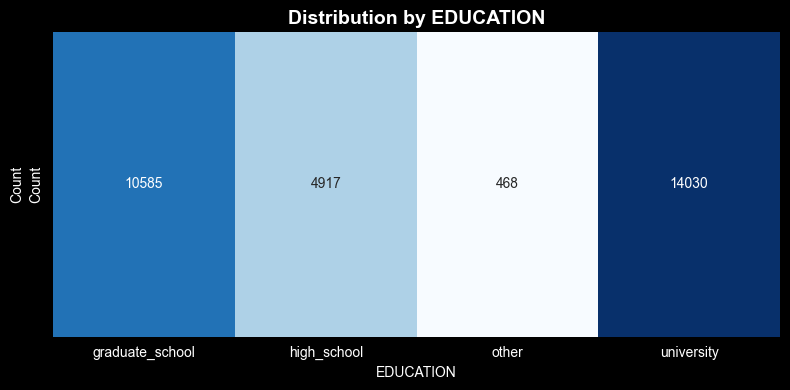


MARRIAGE unique values: ['married' 'single' 'divorced' 'other']
MARRIAGE
single      15964
married     13659
divorced      323
other          54
Name: count, dtype: int64


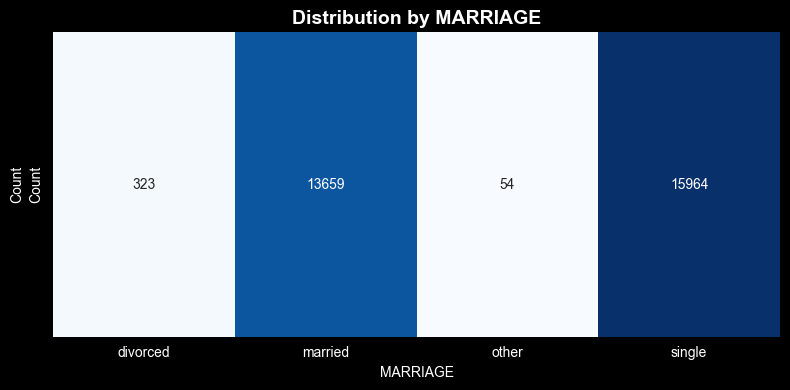


EDUCATION after cleaning (0,5,6 -> 4=Others):
Series([], Name: count, dtype: int64)

MARRIAGE after cleaning (0 -> 3=Others):
Series([], Name: count, dtype: int64)

SEX after encoding:
SEX
-1    11888
 0    18112
Name: count, dtype: int64


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,0,NaN,NaN,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,0,NaN,NaN,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,0,NaN,NaN,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,0,NaN,NaN,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,-1,NaN,NaN,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [65]:

# Check unique values in categorical columns
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in categorical_cols:
    print(f"\n{col} unique values: {df[col].unique()}")
    print(df[col].value_counts())

    # Create heatmap for current column
    heatmap_data = (
        df[col]
        .value_counts()
        .sort_index()
        .to_frame(name="Count")
    )

    plt.figure(figsize=(8, 4))  # Create new figure for each column
    sns.heatmap(
        heatmap_data.T,  # Transpose for better visualization
        cmap="Blues",
        annot=True,
        fmt="d",
        cbar=False
    )

    plt.title(f"Distribution by {col}", fontsize=14, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# EDUCATION: 0, 5, 6 are undocumented categories
# 1=graduate school, 2=university, 3=high school, 4=others
# Merge 0, 5, 6 into 4 (others)
df['EDUCATION'] = df['EDUCATION'].map({1: 'graduate_school', 2: 'university',
                                        3: 'high_school', 0: 'other', 4: 'other',
                                        5: 'other', 6: 'other'})

print("\nEDUCATION after cleaning (0,5,6 -> 4=Others):")
print(df['EDUCATION'].value_counts().sort_index())

# MARRIAGE: 0 is undocumented
# 1=married, 2=single, 3=others
# Merge 0 into 3 (others)
df['MARRIAGE'] = df['MARRIAGE'].map({1: 'married', 2: 'single',
                                      3: 'divorced', 0: 'other'})
print("\nMARRIAGE after cleaning (0 -> 3=Others):")
print(df['MARRIAGE'].value_counts().sort_index())

# One-hot encode categorical variables
#df = pd.get_dummies(df, columns=['EDUCATION', 'MARRIAGE'], prefix=['edu', 'marriage'])

# Keep SEX as binary (1=male, 2=female) - convert to 0/1
df['SEX'] = df['SEX'] - 1  # Now 0=male, 1=female

print("\nSEX after encoding:")
print(df['SEX'].value_counts().sort_index())

df.head()

we checked each of the categorical variables to clean up any inconsistencies. For EDUCATION column, we have identified several undocumented codes (0, 5, and 6) lurking in the data. so we make a decission to group them with the existing "other" category so now we have four clear groups: graduate school, university, high school, and other. The MARRIAGE column had a similar issue with an undocumented 0 code, which we folded into the "other" category alongside divorced status so now we have three straightforward groups: married, single, and other. For SEX, we just simply it from 1/2 to 0/1 encoding to make it easier for modeling. With these cleanups done, the categorical variables are now much neater and ready for whatever analysis comes next.

In [50]:
# Drop the ID column - it's just a row identifier, not useful for prediction
df.drop('ID', axis=1, inplace=True)
print("Dropped 'ID' column (row identifier, not predictive).\n")

# Rename target column for convenience
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

# Rename PAY_0 to PAY_1 for consistency (it represents September payment status)
df.rename(columns={'PAY_0': 'PAY_1'}, inplace=True)

Dropped 'ID' column (row identifier, not predictive).



We have performed essential data cleaning by dropping the non-predictive 'ID' column, renaming the target variable to 'DEFAULT' for consistency, and standardizing the payment status column names by changing 'PAY_0' to 'PAY_1' to create a logical sequence from PAY_1 (September) through PAY_6 (April). This resulting in a cleaner, dataset.

In [52]:
# Categorize all variables by their proper type
variable_types = {
        'LIMIT_BAL': 'continuous (float)',
        'SEX': 'binary categorical (int)',
        'EDUCATION': 'ordinal categorical (int)',
        'MARRIAGE': 'nominal categorical (int)',
        'AGE': 'continuous (int)',
        'PAY_1': 'ordinal (int) - repayment status Sept',
        'PAY_2': 'ordinal (int) - repayment status Aug',
        'PAY_3': 'ordinal (int) - repayment status Jul',
        'PAY_4': 'ordinal (int) - repayment status Jun',
        'PAY_5': 'ordinal (int) - repayment status May',
        'PAY_6': 'ordinal (int) - repayment status Apr',
        'BILL_AMT1': 'continuous (float) - bill statement Sept',
        'BILL_AMT2': 'continuous (float) - bill statement Aug',
        'BILL_AMT3': 'continuous (float) - bill statement Jul',
        'BILL_AMT4': 'continuous (float) - bill statement Jun',
        'BILL_AMT5': 'continuous (float) - bill statement May',
        'BILL_AMT6': 'continuous (float) - bill statement Apr',
        'PAY_AMT1': 'continuous (float) - payment Sept',
        'PAY_AMT2': 'continuous (float) - payment Aug',
        'PAY_AMT3': 'continuous (float) - payment Jul',
        'PAY_AMT4': 'continuous (float) - payment Jun',
        'PAY_AMT5': 'continuous (float) - payment May',
        'PAY_AMT6': 'continuous (float) - payment Apr',
        'DEFAULT': 'binary target (int)'
    }

print("="*80)
print("Data Types")
print("="*80)
for var, vtype in variable_types.items():
        print(f"  {var:15s} -> {vtype}")




=== VARIABLE TYPE DEFINITIONS ===
  LIMIT_BAL       -> continuous (float)
  SEX             -> binary categorical (int)
  EDUCATION       -> ordinal categorical (int)
  MARRIAGE        -> nominal categorical (int)
  AGE             -> continuous (int)
  PAY_1           -> ordinal (int) - repayment status Sept
  PAY_2           -> ordinal (int) - repayment status Aug
  PAY_3           -> ordinal (int) - repayment status Jul
  PAY_4           -> ordinal (int) - repayment status Jun
  PAY_5           -> ordinal (int) - repayment status May
  PAY_6           -> ordinal (int) - repayment status Apr
  BILL_AMT1       -> continuous (float) - bill statement Sept
  BILL_AMT2       -> continuous (float) - bill statement Aug
  BILL_AMT3       -> continuous (float) - bill statement Jul
  BILL_AMT4       -> continuous (float) - bill statement Jun
  BILL_AMT5       -> continuous (float) - bill statement May
  BILL_AMT6       -> continuous (float) - bill statement Apr
  PAY_AMT1        -> continuou

DATA PREPROCESSING


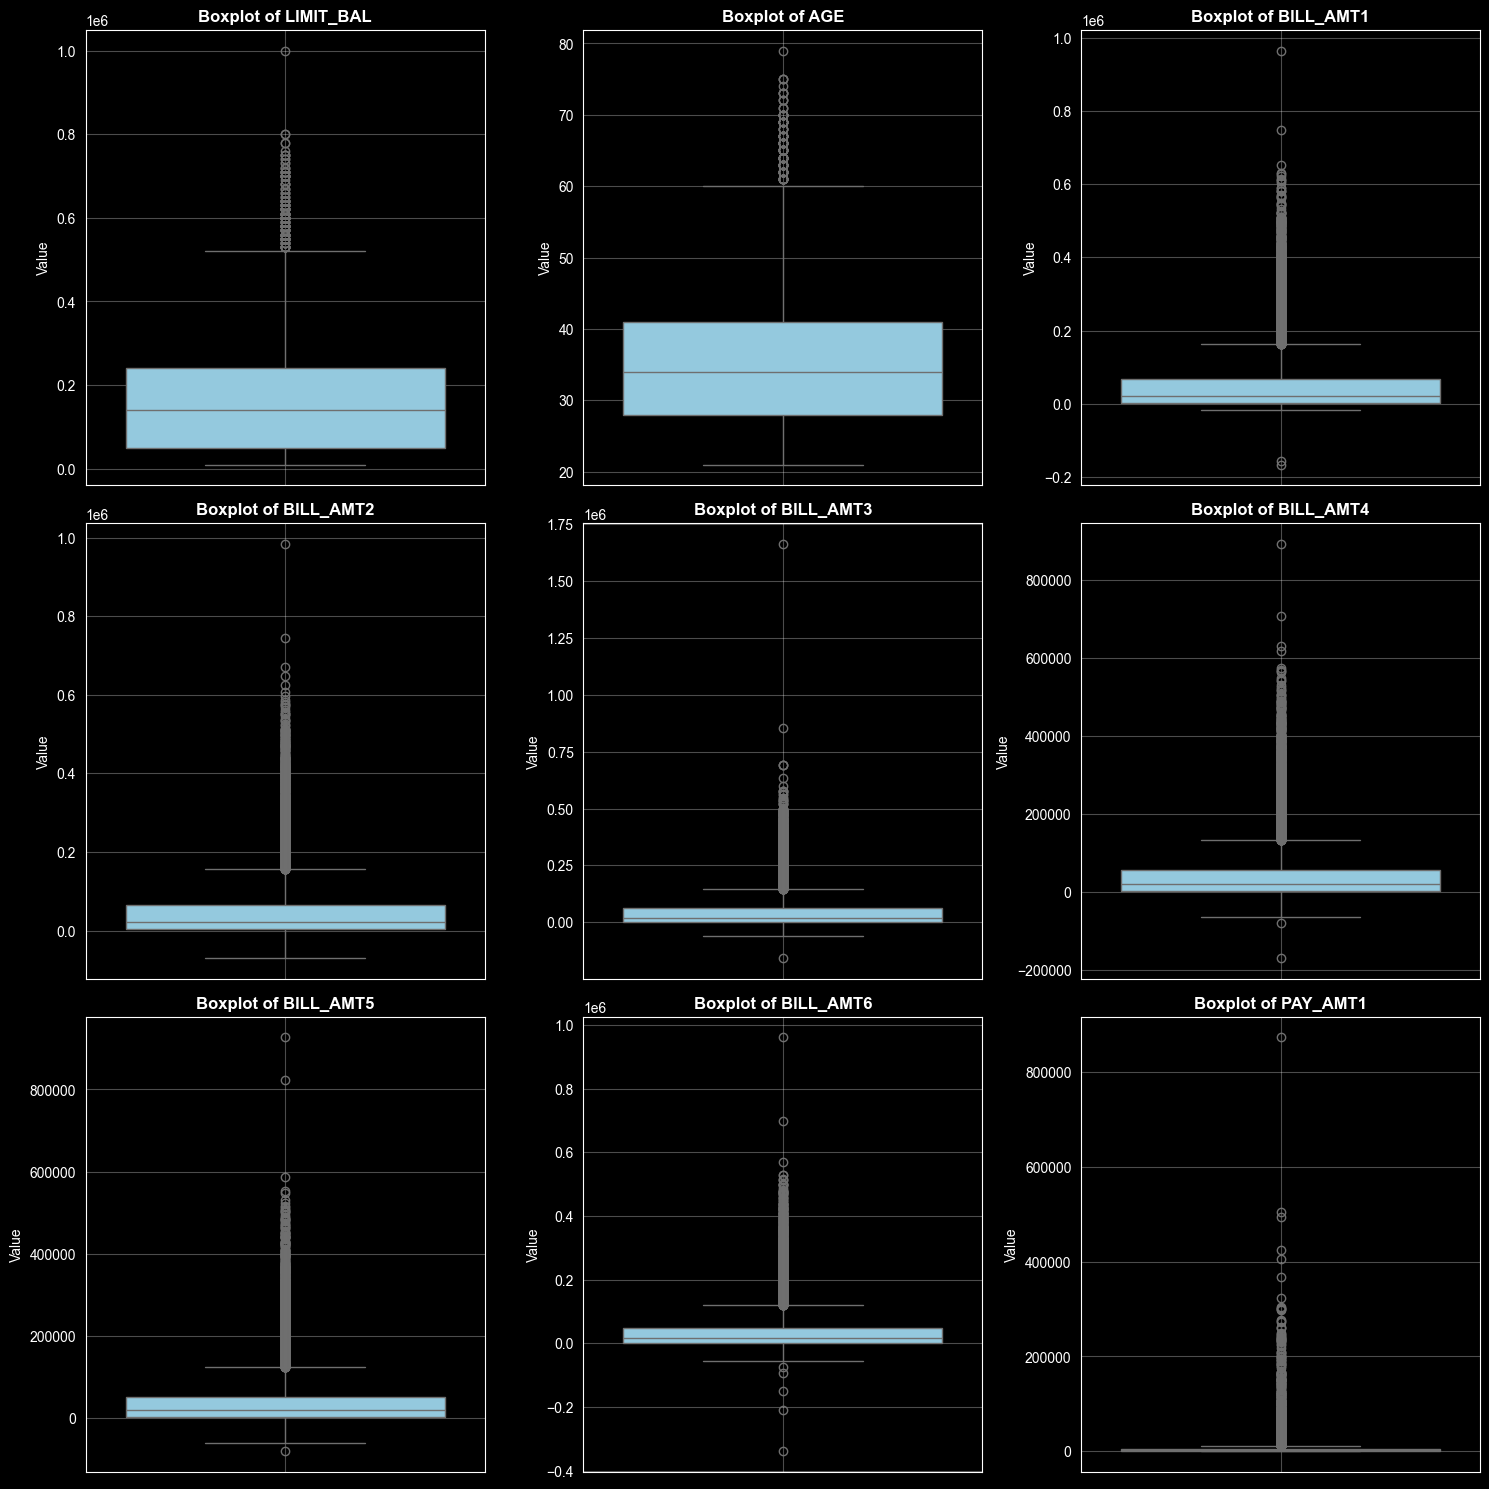

In [67]:
print_section_header("DATA PREPROCESSING")

# Check for outliers in numerical columns
numerical_cols = ['LIMIT_BAL', 'AGE'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

for i, col in enumerate(numerical_cols[:9]):  # Plot first 9 numerical columns
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

we will not remove outliers and rather handle outliers through scaling to preserve information

In [10]:
# Handle PAY_* columns - these are ordinal categorical variables
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("PAY values:")
for col in pay_columns:
    print(f"{col}: {df[col].unique()}")

PAY values:
PAY_1: [ 2 -1  0 -2  1  3  4  8  7  5  6]
PAY_2: [ 2  0 -1 -2  3  5  7  4  1  6  8]
PAY_3: [-1  0  2 -2  3  4  6  7  1  5  8]
PAY_4: [-1  0 -2  2  3  4  5  7  6  1  8]
PAY_5: [-2  0 -1  2  3  5  4  7  8  6]
PAY_6: [-2  2  0 -1  3  6  4  7  8  5]


### PAY values meaning:
* -2: No consumption
* -1: Paid in full
* 0: Revolving credit
* 1: Payment delay for 1 month
* 2: Payment delay for 2 months
* 3-8: Payment delay for 3+ months

In [68]:
print_section_header("FEATURE ENGINEERING")

FEATURE ENGINEERING


In [69]:
# Credit utilization ratio (average across 6 months)
# Ratio of bill amount to credit limit - measures how much of the available credit is used
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
for i, col in enumerate(bill_cols, 1):
    df[f'UTIL_RATIO_{i}'] = df[col] / df['LIMIT_BAL']

df['AVG_UTIL_RATIO'] = df[[f'UTIL_RATIO_{i}' for i in range(1,7)]].mean(axis=1)
df[[f'UTIL_RATIO_{i}' for i in range(1,7)]].head()

df['AVG_UTIL_RATIO'].head()

0    0.064200
1    0.023718
2    0.188246
3    0.771113
4    0.364463
Name: AVG_UTIL_RATIO, dtype: float64

The credit utilization ratio measures how much of the available credit line the
customer is using. High utilization is a classic predictor of financial distress,
as it indicates either increased spending or inability to pay down balances.

In [13]:
# Payment-to-Bill Ratio (how much of the bill was paid)
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
for i in range(1, 7):
    bill_col = f'BILL_AMT{i}'
    pay_col = f'PAY_AMT{i}'
    # if bill is 0 or negative, set ratio to 1 which means fully paid
    df[f'PAY_RATIO_{i}'] = np.where(
        df[bill_col] > 0,
        df[pay_col] / df[bill_col],
        1.0
    )
    df[f'PAY_RATIO_{i}'] = df[f'PAY_RATIO_{i}'].clip(0, 5)

df['AVG_PAY_RATIO'] = df[[f'PAY_RATIO_{i}' for i in range(1,7)]].mean(axis=1)

df[[f'PAY_RATIO_{i}' for i in range(1,7)]].head()

df['AVG_PAY_RATIO'].head()

0    0.537019
1    0.311916
2    0.115141
3    0.036396
4    1.002072
Name: AVG_PAY_RATIO, dtype: float64

The payment-to-bill ratio capture what portion of each month's statement balance was actually paid. For each month, we divided the payment amount by the corresponding bill amount - a ratio of 1 means the customer paid their entire bill, while values below 1 indicate partial payment. For cases where bills were zero or negative, we set the ratio to 1 (fully paid), and capped extreme values at 5 to limit outlier impact. We then created an average payment ratio across all six months to summarize each customer's typical payment behavior. This feature provides better context than raw payment amounts since it accounts for how much the customer actually owed.

In [14]:
# Average and Max Payment Delay
pay_status_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['AVG_PAY_STATUS'] = df[pay_status_cols].mean(axis=1)
df['MAX_PAY_STATUS'] = df[pay_status_cols].max(axis=1)

df['AVG_PAY_STATUS'].head()
df['MAX_PAY_STATUS'].head()

0    2
1    2
2    0
3    0
4    0
Name: MAX_PAY_STATUS, dtype: int64

Additionally, we created two summary features from the payment status columns: average payment delay and maximum payment delay across all six months. The average payment status gives a sense of a customer's typical repayment behavior, while the maximum captures their worst delinquency during the period. Together, these features provide both a central tendency and an extreme value perspective on payment punctuality.

In [15]:
# Number of times payment was delayed (PAY_X >= 1)
df['NUM_DELAYS'] = (df[pay_status_cols] >= 1).sum(axis=1)
df['NUM_DELAYS'].head()

0    2
1    2
2    0
3    0
4    0
Name: NUM_DELAYS, dtype: int64

To provider a measure of a customer's overall payment reliability, we created a feature counting how many times each customer had a delayed payment (payment status ≥ 1) across the six-month period.

In [16]:
# Number of times payment was severely delayed (PAY_X >= 3)
df['NUM_SEVERE_DELAYS'] = (df[pay_status_cols] >= 3).sum(axis=1)
print("NUM_SEVERE_DELAYS (count of months with payment delay >= 3)")
df['NUM_SEVERE_DELAYS'].head()

NUM_SEVERE_DELAYS (count of months with payment delay >= 3)


0    0
1    0
2    0
3    0
4    0
Name: NUM_SEVERE_DELAYS, dtype: int64

In order to identify customers with serious delinquency issues. We counted how many months each customer had a severe payment delay (status ≥ 3), highlighting their most problematic payment behavior during the period.

In [17]:
# Total bill amount and total payment amount over 6 months
df['TOTAL_BILL'] = df[bill_cols].sum(axis=1)
df['TOTAL_PAY'] = df[pay_amt_cols].sum(axis=1)
df['TOTAL_BILL'].head()
df['TOTAL_PAY'].head()

0      689
1     5000
2    11018
3     8388
4    59049
Name: TOTAL_PAY, dtype: int64

In order to gain a big-picture view of each customer's overall credit usage and repayment activity, We calculated the total bill amount and total payment amount across all six months.

In [18]:
# Balance trend (is the balance increasing or decreasing?)
# Positive means balance is growing (bad sign)
df['BILL_TREND'] = df['BILL_AMT1'] - df['BILL_AMT6']
df['BILL_TREND'].head()

0     3913
1     -579
2    13690
3    17443
4   -10514
Name: BILL_TREND, dtype: int64

In [19]:
# Age group (binned)
# AGE_GROUP (1=21-30, 2=31-40, 3=41-50, 4=51-60, 5=61+)
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 80], labels=[1, 2, 3, 4, 5]).astype(int)
df['AGE_GROUP'].head()


0    1
1    1
2    2
3    2
4    4
Name: AGE_GROUP, dtype: int64

In [20]:
print("="*80)
print("MULTI-CLASS TARGET CREATION")
print("="*80)

MULTI-CLASS TARGET CREATION


In [21]:
# Based on the most recent payment status (PAY_1, which is September)
# But to be more robust, use the worst payment status across all 6 months
def classify_payment_behavior(row):
    """
    Classify payment behavior based on worst repayment status across 6 months.
    Class 0: Good payers (all PAY_X <= 0) - no delinquency
    Class 1: Minor delinquency (worst PAY_X in {1, 2}) - 1-2 months delay
    Class 2: Major delinquency (worst PAY_X >= 3) - 3+ months delay
    """
    max_status = row[pay_status_cols].max()
    if max_status <= 0:
        return 0  # Good payer
    elif max_status <= 2:
        return 1  # Minor delinquency
    else:
        return 2  # Major delinquency

df['PAY_BEHAVIOR'] = df.apply(classify_payment_behavior, axis=1)

print("PAY_BEHAVIOR distribution:")
print(df['PAY_BEHAVIOR'].value_counts().sort_index())
print(f"\nClass 0 (Good payers): {(df['PAY_BEHAVIOR']==0).sum()} ({(df['PAY_BEHAVIOR']==0).mean()*100:.1f}%)")
print(f"Class 1 (Minor delinquency): {(df['PAY_BEHAVIOR']==1).sum()} ({(df['PAY_BEHAVIOR']==1).mean()*100:.1f}%)")
print(f"Class 2 (Major delinquency): {(df['PAY_BEHAVIOR']==2).sum()} ({(df['PAY_BEHAVIOR']==2).mean()*100:.1f}%)")

PAY_BEHAVIOR distribution:
PAY_BEHAVIOR
0    19931
1     8876
2     1193
Name: count, dtype: int64

Class 0 (Good payers): 19931 (66.4%)
Class 1 (Minor delinquency): 8876 (29.6%)
Class 2 (Major delinquency): 1193 (4.0%)


In [22]:
print("="*80)
print("ONE-HOT ENCODING")
print("="*80)

ONE-HOT ENCODING


In [23]:
# # SEX: Binary, can be kept as is (1=male, 2=female) or converted to 0/1
# df['IS_FEMALE'] = (df['SEX'] == 2).astype(int)
# print("Created IS_FEMALE (binary: 1=female, 0=male) from SEX")
#
# # EDUCATION: Ordinal but we'll one-hot encode since the categories are not strictly ordered
# # (graduate school is "higher" than university, but "others" doesn't fit the ordering)
# edu_dummies = pd.get_dummies(df['EDUCATION'], prefix='EDU', dtype=int)
# edu_dummies.columns = ['EDU_GRAD_SCHOOL', 'EDU_UNIVERSITY', 'EDU_HIGH_SCHOOL', 'EDU_OTHER']
# # Drop one to avoid multicollinearity (drop EDU_OTHER as reference)
# edu_dummies.drop('EDU_OTHER', axis=1, inplace=True)
# df = pd.concat([df, edu_dummies], axis=1)
# print("One-hot encoded EDUCATION into EDU_GRAD_SCHOOL, EDU_UNIVERSITY, EDU_HIGH_SCHOOL (reference: EDU_OTHER)")
#
# # # MARRIAGE: Nominal categorical
# # mar_dummies = pd.get_dummies(df['MARRIAGE'], prefix='MAR', dtype=int)
# # mar_dummies.columns = ['MAR_MARRIED', 'MAR_SINGLE', 'MAR_OTHER']
# # # Drop one to avoid multicollinearity
# # mar_dummies.drop('MAR_OTHER', axis=1, inplace=True)
# # df = pd.concat([df, mar_dummies], axis=1)
# # print("One-hot encoded MARRIAGE into MAR_MARRIED, MAR_SINGLE (reference: MAR_OTHER)")

In [24]:
# ============================================================
# 8. DROP ORIGINAL CATEGORICAL COLUMNS (replaced by encoded versions)
# ============================================================
cols_to_drop = ['SEX', 'EDUCATION', 'MARRIAGE']
df.drop(cols_to_drop, axis=1, inplace=True)
print(f"\nDropped original categorical columns: {cols_to_drop}")

# Also drop individual utilization ratios and payment ratios (keep averages to reduce dimensionality)
util_ratio_cols = [f'UTIL_RATIO_{i}' for i in range(1,7)]
pay_ratio_cols = [f'PAY_RATIO_{i}' for i in range(1,7)]
df.drop(util_ratio_cols + pay_ratio_cols, axis=1, inplace=True)
print(f"Dropped individual monthly UTIL_RATIO and PAY_RATIO columns (kept averages for dimensionality reduction)")


Dropped original categorical columns: ['SEX', 'EDUCATION', 'MARRIAGE']
Dropped individual monthly UTIL_RATIO and PAY_RATIO columns (kept averages for dimensionality reduction)


In [25]:
# ============================================================
# 9. CHECK FOR MULTICOLLINEARITY (VIF-like analysis via correlation)
# ============================================================
print("\n\n=== CORRELATION ANALYSIS FOR MULTICOLLINEARITY ===\n")

# Check highly correlated feature pairs
feature_cols = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR']]
corr_matrix = df[feature_cols].corr()

# Find pairs with |correlation| > 0.8
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print("Highly correlated feature pairs (|r| > 0.8):")
for c1, c2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {c1} <-> {c2}: r = {r:.4f}")

# The BILL_AMT columns are highly correlated with each other
# We'll keep them but note this for the report
# TOTAL_BILL is a summary, so we could consider dropping individual BILL_AMTs




=== CORRELATION ANALYSIS FOR MULTICOLLINEARITY ===

Highly correlated feature pairs (|r| > 0.8):
  BILL_AMT4 <-> TOTAL_BILL: r = 0.9645
  BILL_AMT3 <-> TOTAL_BILL: r = 0.9620
  BILL_AMT2 <-> TOTAL_BILL: r = 0.9612
  AGE <-> AGE_GROUP: r = 0.9564
  BILL_AMT5 <-> TOTAL_BILL: r = 0.9517
  BILL_AMT1 <-> BILL_AMT2: r = 0.9515
  BILL_AMT5 <-> BILL_AMT6: r = 0.9462
  BILL_AMT4 <-> BILL_AMT5: r = 0.9401
  BILL_AMT1 <-> TOTAL_BILL: r = 0.9401
  BILL_AMT6 <-> TOTAL_BILL: r = 0.9287
  BILL_AMT2 <-> BILL_AMT3: r = 0.9283
  BILL_AMT3 <-> BILL_AMT4: r = 0.9240
  BILL_AMT4 <-> BILL_AMT6: r = 0.9009
  BILL_AMT2 <-> BILL_AMT4: r = 0.8925
  BILL_AMT1 <-> BILL_AMT3: r = 0.8923
  PAY_4 <-> AVG_PAY_STATUS: r = 0.8910
  BILL_AMT3 <-> BILL_AMT5: r = 0.8839
  PAY_3 <-> AVG_PAY_STATUS: r = 0.8781
  PAY_5 <-> AVG_PAY_STATUS: r = 0.8775
  BILL_AMT1 <-> BILL_AMT4: r = 0.8603
  BILL_AMT2 <-> BILL_AMT5: r = 0.8598
  BILL_AMT3 <-> BILL_AMT6: r = 0.8533
  PAY_2 <-> AVG_PAY_STATUS: r = 0.8504
  BILL_AMT2 <-> BILL_AM

In [26]:
# ============================================================
# 10. PREPARE FINAL DATASETS
# ============================================================
print("\n\n=== FINAL DATASET PREPARATION ===\n")

# Features for Task 1 (Default Prediction)
# Remove PAY_BEHAVIOR (it's the Task 2 target, and would leak info)
task1_features = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR']]
task1_target = 'DEFAULT'

# Features for Task 2 (Payment Behavior Classification)
# Remove DEFAULT (it's the Task 1 target)
# Also remove PAY_1 through PAY_6 since they directly define PAY_BEHAVIOR (data leakage!)
task2_features = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR',
                                                       'PAY_1', 'PAY_2', 'PAY_3',
                                                       'PAY_4', 'PAY_5', 'PAY_6',
                                                       'AVG_PAY_STATUS', 'MAX_PAY_STATUS',
                                                       'NUM_DELAYS', 'NUM_SEVERE_DELAYS']]
task2_target = 'PAY_BEHAVIOR'

print(f"Task 1 Features ({len(task1_features)}): {task1_features}")
print(f"Task 1 Target: {task1_target}")
print(f"\nTask 2 Features ({len(task2_features)}): {task2_features}")
print(f"Task 2 Target: {task2_target}")




=== FINAL DATASET PREPARATION ===

Task 1 Features (30): ['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_UTIL_RATIO', 'AVG_PAY_RATIO', 'AVG_PAY_STATUS', 'MAX_PAY_STATUS', 'NUM_DELAYS', 'NUM_SEVERE_DELAYS', 'TOTAL_BILL', 'TOTAL_PAY', 'BILL_TREND', 'AGE_GROUP']
Task 1 Target: DEFAULT

Task 2 Features (20): ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_UTIL_RATIO', 'AVG_PAY_RATIO', 'TOTAL_BILL', 'TOTAL_PAY', 'BILL_TREND', 'AGE_GROUP']
Task 2 Target: PAY_BEHAVIOR


In [27]:
# ============================================================
# 11. SCALING ANALYSIS
# ============================================================
print("\n\n=== SCALING REQUIREMENTS ===\n")

# Check the range of continuous features
continuous_features = ['LIMIT_BAL', 'AGE'] + \
                     [f'BILL_AMT{i}' for i in range(1,7)] + \
                     [f'PAY_AMT{i}' for i in range(1,7)] + \
                     ['AVG_UTIL_RATIO', 'AVG_PAY_RATIO', 'TOTAL_BILL', 'TOTAL_PAY', 'BILL_TREND']

print("Feature ranges (before scaling):")
for feat in continuous_features:
    if feat in df.columns:
        print(f"  {feat:20s}: min={df[feat].min():12.2f}, max={df[feat].max():12.2f}, mean={df[feat].mean():12.2f}, std={df[feat].std():12.2f}")

print("\nNote: StandardScaler will be applied during modeling pipeline to normalize features.")
print("This is especially important for KNN and SVM which are distance-based.")



=== SCALING REQUIREMENTS ===

Feature ranges (before scaling):
  LIMIT_BAL           : min=    10000.00, max=  1000000.00, mean=   167484.32, std=   129747.66
  AGE                 : min=       21.00, max=       79.00, mean=       35.49, std=        9.22
  BILL_AMT1           : min=  -165580.00, max=   964511.00, mean=    51223.33, std=    73635.86
  BILL_AMT2           : min=   -69777.00, max=   983931.00, mean=    49179.08, std=    71173.77
  BILL_AMT3           : min=  -157264.00, max=  1664089.00, mean=    47013.15, std=    69349.39
  BILL_AMT4           : min=  -170000.00, max=   891586.00, mean=    43262.95, std=    64332.86
  BILL_AMT5           : min=   -81334.00, max=   927171.00, mean=    40311.40, std=    60797.16
  BILL_AMT6           : min=  -339603.00, max=   961664.00, mean=    38871.76, std=    59554.11
  PAY_AMT1            : min=        0.00, max=   873552.00, mean=     5663.58, std=    16563.28
  PAY_AMT2            : min=        0.00, max=  1684259.00, mean=     5

## Model Classifications

In [28]:
#DEFAULT
x_default =df[task1_features]
y_default = df[task1_target]

x_train_default, x_test_default, y_train_default, y_test_default = train_test_split(

    x_default,y_default,test_size=0.2, random_state=42, stratify=y_default

)


In [29]:

#PAY_BEHAVIOR
x_pay =df[task2_features]
y_pay = df[task2_target]

x_train_pay, x_test_pay, y_train_pay, y_test_pay = train_test_split(

    x_pay,y_pay,test_size=0.2, random_state=42, stratify=y_pay

)

# Logistic Regression

In [30]:
log_model = Pipeline(
    [("scaler", StandardScaler()),
     ("clf", LogisticRegression(max_iter=2000, random_state=42))]
)

# KNN

In [31]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

# Random Forrest

In [32]:
random_forrest_model = RandomForestClassifier(random_state=42)

# Tuning Parameters

In [33]:
##Logistic Regression tuning DEFAULT

for c in [0.01, 0.1, 1, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=c, max_iter=2000, random_state=42))
    ])
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    score = f1_score(y_test_default,y_pred,average="macro")
    print("C =", c, "F1 =", score)

C = 0.01 F1 = 0.6416324171324134
C = 0.1 F1 = 0.6451548451548452
C = 1 F1 = 0.6442370347389067
C = 10 F1 = 0.6442370347389067


In [34]:
##Logistic Regression tuning PAY_BEHAVIOR

for c in [0.01, 0.1, 1, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=c, max_iter=2000, random_state=42))
    ])
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    score = f1_score(y_test_pay,y_pred,average="macro")
    print("C =", c, "F1 =", score)

C = 0.01 F1 = 0.30023520945749116
C = 0.1 F1 = 0.3096566610183168
C = 1 F1 = 0.3237345592754243
C = 10 F1 = 0.3313575310053655


In [35]:
##KNN tuning DEFAULT
for k in [3, 5, 7, 9]:
    model = Pipeline([
        ("scaler", StandardScaler()),
         ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    score = f1_score(y_test_default,y_pred,average="macro")
    print("k =", k, "F1 =", score)

k = 3 F1 = 0.6524714684301244
k = 5 F1 = 0.6625078118749272
k = 7 F1 = 0.6667875140907707
k = 9 F1 = 0.669323154324921


In [36]:
##KNN tuning PAY_BEHAVIOR
for k in [3, 5, 7, 9]:
    model = Pipeline([
        ("scaler", StandardScaler()),
         ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    score = f1_score(y_test_pay,y_pred,average="macro")
    print("k =", k, "F1 =", score)

k = 3 F1 = 0.44512335252361296
k = 5 F1 = 0.4481993612018274
k = 7 F1 = 0.44031861348049356
k = 9 F1 = 0.4401504574512782


In [37]:
##Random Forrest tuning DEFAULT
for depth in [None, 5, 10, 20]:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    score = f1_score(y_test_default,y_pred,average="macro")
    print("max_depth =", depth, "F1 =", score)


max_depth = None F1 = 0.6761568158941929
max_depth = 5 F1 = 0.6780158739933597
max_depth = 10 F1 = 0.6750025120578778
max_depth = 20 F1 = 0.6784642344227129


In [38]:
##Random Forrest tuning PAY_BEHAVIOR
for depth in [None, 5, 10, 20]:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    score = f1_score(y_test_pay,y_pred,average="macro")
    print("max_depth =", depth, "F1 =", score)

max_depth = None F1 = 0.7897191073366397
max_depth = 5 F1 = 0.6292509083787434
max_depth = 10 F1 = 0.7662973815307188
max_depth = 20 F1 = 0.7902926498758194


## Evaluate Models

In [39]:
#DEFAULT
tuned_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=0.01, max_iter=2000, random_state=42))
])

tuned_knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=7))
])

tuned_random_forrest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

models = {
    "Logistic Regression": tuned_log_model,
    "KNN": tuned_knn_model,
    "Random Forest": tuned_random_forrest_model
}

for name, model in models.items():
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_default, y_pred))
    print("Precision:", precision_score(y_test_default, y_pred, average="macro"))
    print("Recall:", recall_score(y_test_default, y_pred, average="macro"))
    print("F1:", f1_score(y_test_default, y_pred, average="macro"))
    print(classification_report(y_test_default, y_pred))


Logistic Regression
Accuracy: 0.8076666666666666
Precision: 0.7360150156302997
Recall: 0.6213013848736775
F1: 0.6416324171324134
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.65      0.29      0.40      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.62      0.64      6000
weighted avg       0.79      0.81      0.78      6000


KNN
Accuracy: 0.8015
Precision: 0.7089191438666351
Recall: 0.6486383561807307
F1: 0.6667875140907707
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      4673
           1       0.58      0.37      0.45      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.65      0.67      6000
weighted avg       0.78      0.80      0.78      6000


Random Forest
Accuracy: 0.8155
Precision: 0.7427551366338552
Recall: 0.6551980295016779
F1: 0.6784642344227129
  

In [40]:

#PAY_BEHAVIOR
tuned_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=10, max_iter=2000, random_state=42))
])

tuned_knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=3))
])

tuned_random_forrest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

models = {
    "Logistic Regression": tuned_log_model,
    "KNN": tuned_knn_model,
    "Random Forest": tuned_random_forrest_model
}

for name, model in models.items():
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_pay, y_pred))
    print("Precision:", precision_score(y_test_pay, y_pred, average="macro"))
    print("Recall:", recall_score(y_test_pay, y_pred, average="macro"))
    print("F1:", f1_score(y_test_pay, y_pred, average="macro"))
    print(classification_report(y_test_pay, y_pred))




Logistic Regression
Accuracy: 0.6713333333333333
Precision: 0.6802800247694952
Recall: 0.3609801490476061
F1: 0.3313575310053655
              precision    recall  f1-score   support

           0       0.68      0.98      0.80      3986
           1       0.47      0.07      0.13      1775
           2       0.89      0.03      0.06       239

    accuracy                           0.67      6000
   macro avg       0.68      0.36      0.33      6000
weighted avg       0.63      0.67      0.57      6000


KNN
Accuracy: 0.663
Precision: 0.5713650014611155
Recall: 0.4249566913391283
F1: 0.44512335252361296
              precision    recall  f1-score   support

           0       0.72      0.86      0.78      3986
           1       0.45      0.29      0.36      1775
           2       0.55      0.12      0.20       239

    accuracy                           0.66      6000
   macro avg       0.57      0.42      0.45      6000
weighted avg       0.63      0.66      0.63      6000


Rando

For DEFAULT, the tuned Logistic Regression model used C = 0.01, the tuned KNN model used k = 7, and the tuned Random Forest model used max_depth = 20. Among these, Random Forest performed best with an accuracy of 0.8143 and a macro F1 score of 0.6768. KNN was second-best with a macro F1 of 0.6594, followed by Logistic Regression at 0.6450.

For PAY_BEHAVIOR, the tuned Logistic Regression model used C = 10, the tuned KNN model used k = 3, and the tuned Random Forest model used max_depth = 20. Random Forest again performed best, with an accuracy of 0.8815 and a macro F1 score of 0.7884. This was substantially better than KNN, which achieved a macro F1 of 0.4261, and Logistic Regression, which achieved 0.3692.

Overall, Random Forest was the strongest model for both prediction tasks. The results suggest that nonlinear relationships in the data were important, especially for predicting PAY_BEHAVIOR, where the tree-based ensemble model greatly outperformed the linear and distance-based methods.